In [1]:
# =============================================
# EXAMPLE 2: MNIST Digit Recognition (Classification)
# =============================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Load the MNIST dataset (comes built into Keras!)
print('Loading MNIST dataset...')
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f'\nDataset loaded successfully!')
print(f'Training images shape: {X_train.shape}')
print(f'Training labels shape: {y_train.shape}')
print(f'Test images shape: {X_test.shape}')
print(f'Test labels shape: {y_test.shape}')
print(f'\nPixel value range: {X_train.min()} to {X_train.max()}')
print(f'Unique labels: {np.unique(y_train)}')


/opt/homebrew/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

Dataset loaded successfully!
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)

Pixel value range: 0 to 255
Unique labels: [0 1 2 3 4 5 6 7 8 9]


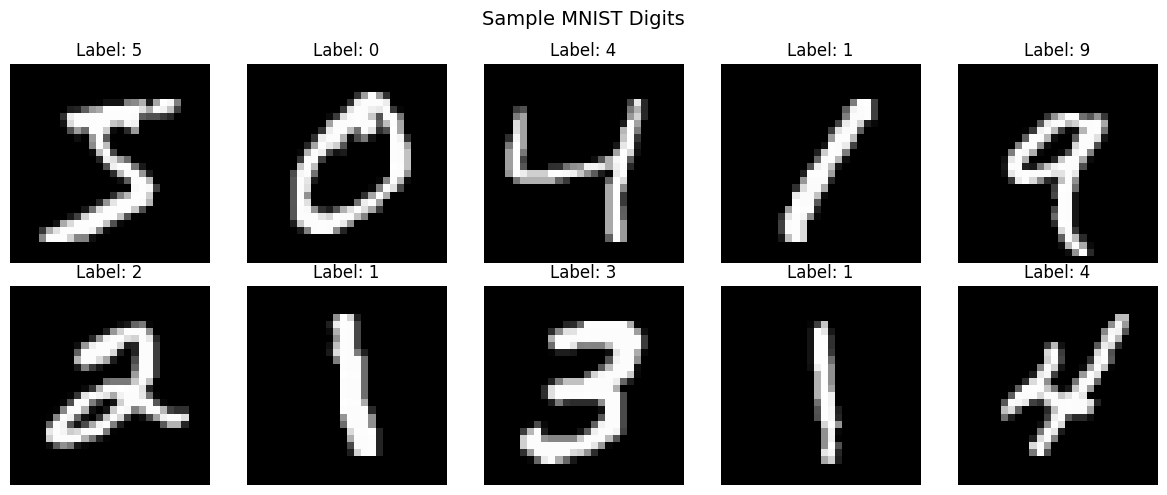


Detailed view of first digit:
This is the digit: 5
Image shape: (28, 28)

Pixel values (first 5 rows):
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


In [2]:
# Visualize some sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample MNIST Digits', fontsize=14)

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}')
    ax.axis('off')

plt.tight_layout()
plt.savefig('mnist_samples.png', dpi=150)
plt.show()

# Visualize a single digit in detail
print('\nDetailed view of first digit:')
print(f'This is the digit: {y_train[0]}')
print(f'Image shape: {X_train[0].shape}')
print('\nPixel values (first 5 rows):')
print(X_train[0][:5])


In [3]:
# PREPROCESSING STEP 1: Flatten 28x28 images to 784-dimensional vectors
# Why? ANNs (Dense layers) expect 1D input
# Shape changes: (60000, 28, 28) -> (60000, 784)

X_train_flat = X_train.reshape(X_train.shape[0], -1)  # -1 means 'calculate automatically'
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f'After flattening:')
print(f'X_train shape: {X_train_flat.shape}')
print(f'X_test shape: {X_test_flat.shape}')

# PREPROCESSING STEP 2: Normalize pixel values to [0, 1]
# Why? Neural networks train better with small input values
# Original range: 0-255, New range: 0-1

X_train_norm = X_train_flat.astype('float32') / 255.0
X_test_norm = X_test_flat.astype('float32') / 255.0

print(f'\nAfter normalization:')
print(f'Pixel value range: {X_train_norm.min():.2f} to {X_train_norm.max():.2f}')

# PREPROCESSING STEP 3: One-hot encode labels
# Why? For multi-class classification with softmax output
# Original label 5 becomes [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]

num_classes = 10
y_train_onehot = keras.utils.to_categorical(y_train, num_classes)
y_test_onehot = keras.utils.to_categorical(y_test, num_classes)

print(f'\nAfter one-hot encoding:')
print(f'y_train shape: {y_train_onehot.shape}')
print(f'Example: Label {y_train[0]} becomes {y_train_onehot[0]}')


After flattening:
X_train shape: (60000, 784)
X_test shape: (10000, 784)

After normalization:
Pixel value range: 0.00 to 1.00

After one-hot encoding:
y_train shape: (60000, 10)
Example: Label 5 becomes [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [4]:
# Build the ANN model for multi-class classification
# Architecture: Input(784) -> Hidden(256, ReLU) -> Hidden(128, ReLU) -> Output(10, Softmax)

model = keras.Sequential([
    # First Hidden Layer: 256 neurons
    # We use more neurons because images have complex patterns
    layers.Dense(256, activation='relu', input_shape=(784,), name='hidden_1'),
    
    # Dropout layer to prevent overfitting
    # Randomly 'turns off' 20% of neurons during training
    layers.Dropout(0.2, name='dropout_1'),
    
    # Second Hidden Layer: 128 neurons
    layers.Dense(128, activation='relu', name='hidden_2'),
    
    # Another Dropout layer
    layers.Dropout(0.2, name='dropout_2'),
    
    # Output Layer: 10 neurons (one per digit class)
    # SOFTMAX activation gives probability distribution across classes
    layers.Dense(10, activation='softmax', name='output')
])

print('\n' + '='*60)
print('MNIST DIGIT CLASSIFIER - MODEL ARCHITECTURE')
print('='*60)
model.summary()

# Parameter calculation:
# Hidden 1: (784 × 256) + 256 = 200,960 parameters
# Hidden 2: (256 × 128) + 128 = 32,896 parameters
# Output: (128 × 10) + 10 = 1,290 parameters
# Total trainable: 235,146 parameters



MNIST DIGIT CLASSIFIER - MODEL ARCHITECTURE


/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Compile the model
# - loss='categorical_crossentropy': Standard for multi-class with one-hot labels
# - metrics=['accuracy']: Track classification accuracy

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('\nModel compiled!')
print('Loss: Categorical Cross-Entropy (for multi-class classification)')
print('Optimizer: Adam')

# Train the model
print('\n' + '='*60)
print('TRAINING STARTED')
print('='*60)

history = model.fit(
    X_train_norm, y_train_onehot,
    epochs=15,                    # 15 epochs is usually enough for MNIST
    batch_size=128,               # Larger batch for faster training
    validation_split=0.1,         # 10% for validation
    verbose=1
)

print('\nTraining complete!')



Model compiled!
Loss: Categorical Cross-Entropy (for multi-class classification)
Optimizer: Adam

TRAINING STARTED
Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8945 - loss: 0.3550 - val_accuracy: 0.9643 - val_loss: 0.1179
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9537 - loss: 0.1528 - val_accuracy: 0.9732 - val_loss: 0.0895
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9674 - loss: 0.1071 - val_accuracy: 0.9765 - val_loss: 0.0765
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9735 - loss: 0.0854 - val_accuracy: 0.9788 - val_loss: 0.0762
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9766 - loss: 0.0727 - val_accuracy: 0.9795 - val_loss: 0.0670
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9808 - loss: 0.0602 - val_accuracy: 0.9792 - val_loss: 0.0715
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9829 - loss: 0.0520 - val_accuracy: 0.9803 - val_l


MODEL EVALUATION RESULTS
Test Loss: 0.0659
Test Accuracy: 98.32%

Interpretation: Model correctly identifies 98.3% of digits!


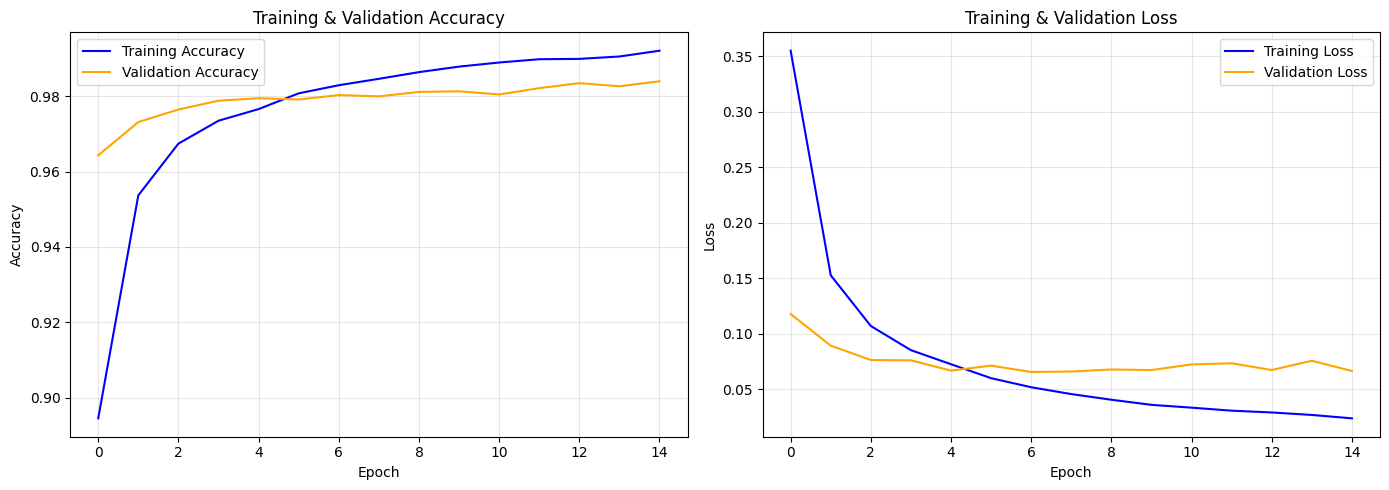

In [6]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test_norm, y_test_onehot, verbose=0)

print('\n' + '='*60)
print('MODEL EVALUATION RESULTS')
print('='*60)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy*100:.2f}%')
print(f'\nInterpretation: Model correctly identifies {test_accuracy*100:.1f}% of digits!')

# Visualize training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy over epochs
axes[0].plot(history.history['accuracy'], label='Training Accuracy', color='blue')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training & Validation Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Loss over epochs
axes[1].plot(history.history['loss'], label='Training Loss', color='blue')
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training & Validation Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mnist_training_history.png', dpi=150)
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 574us/step


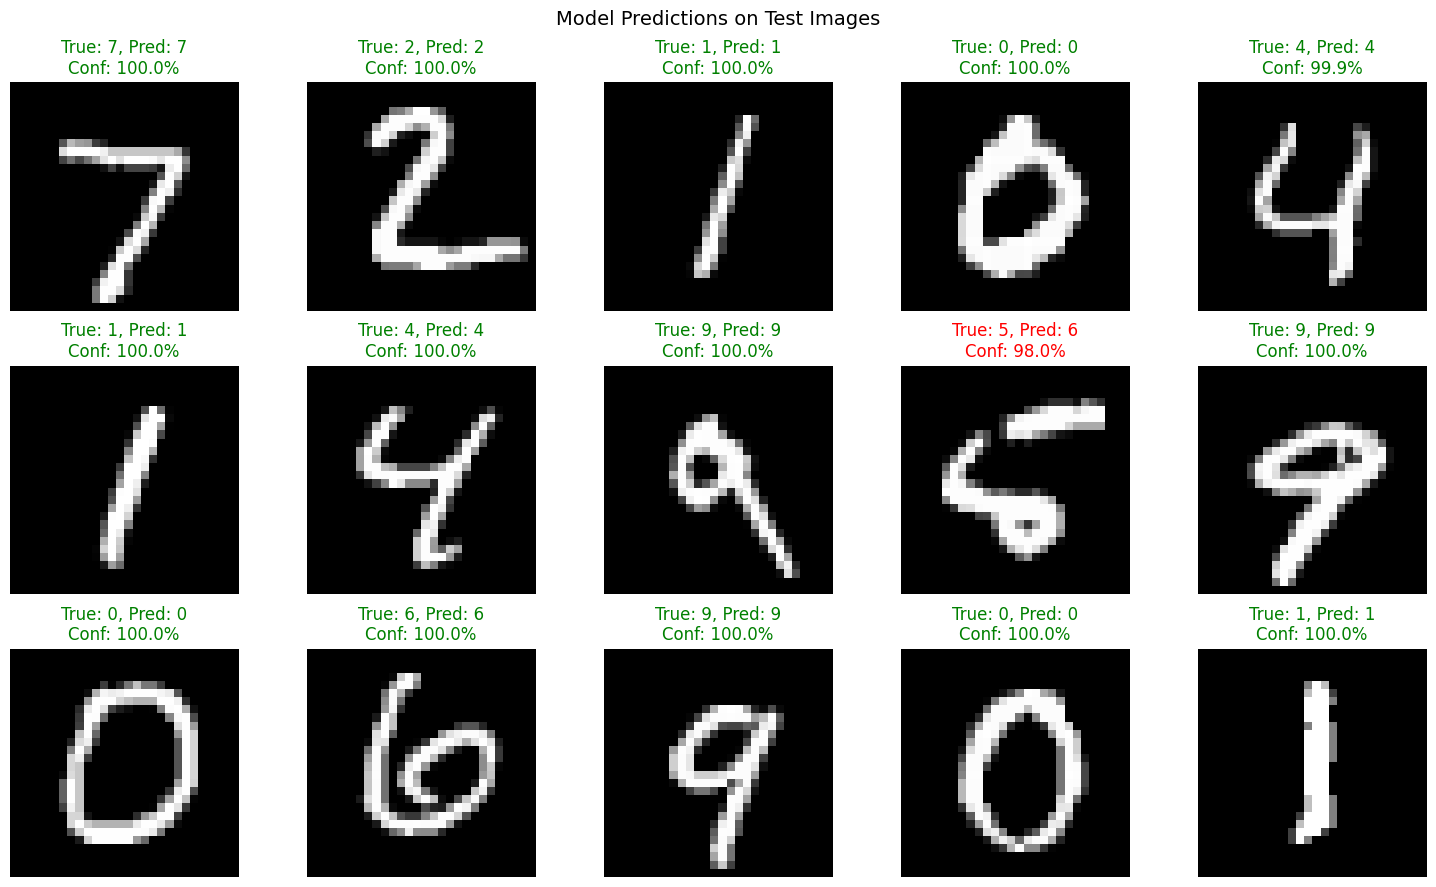

ModuleNotFoundError: No module named 'seaborn'

In [7]:
# Make predictions on test set
y_pred_probs = model.predict(X_test_norm)  # Get probability distributions
y_pred = np.argmax(y_pred_probs, axis=1)   # Get predicted class (highest prob)

# Visualize some predictions
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('Model Predictions on Test Images', fontsize=14)

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
    true_label = y_test[i]
    pred_label = y_pred[i]
    confidence = y_pred_probs[i][pred_label] * 100
    
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f'True: {true_label}, Pred: {pred_label}\nConf: {confidence:.1f}%', 
                 color=color)
    ax.axis('off')

plt.tight_layout()
plt.savefig('mnist_predictions.png', dpi=150)
plt.show()

# Create confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - MNIST Digit Classification')
plt.savefig('mnist_confusion_matrix.png', dpi=150)
plt.show()

# Print detailed classification report
print('\n' + '='*60)
print('DETAILED CLASSIFICATION REPORT')
print('='*60)
print(classification_report(y_test, y_pred, digits=3))


In [ ]:
# Function to test individual images
def predict_digit(image_index):
    """Predict a single digit and show detailed output."""
    # Get the image
    image = X_test[image_index]
    true_label = y_test[image_index]
    
    # Preprocess
    image_flat = image.reshape(1, 784) / 255.0
    
    # Predict
    probs = model.predict(image_flat, verbose=0)[0]
    pred_label = np.argmax(probs)
    
    # Display
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Show image
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title(f'True Label: {true_label}')
    axes[0].axis('off')
    
    # Show probability distribution
    colors = ['green' if i == pred_label else 'gray' for i in range(10)]
    axes[1].bar(range(10), probs * 100, color=colors)
    axes[1].set_xlabel('Digit Class')
    axes[1].set_ylabel('Probability (%)')
    axes[1].set_title(f'Predicted: {pred_label} (Confidence: {probs[pred_label]*100:.1f}%)')
    axes[1].set_xticks(range(10))
    
    plt.tight_layout()
    plt.show()
    
    return pred_label, probs

# Test a few examples
print('Testing individual predictions...')
for idx in [0, 100, 500, 1000, 5000]:
    pred, probs = predict_digit(idx)
    print(f'Index {idx}: Predicted {pred}, True {y_test[idx]}')
